### GLOBAL COMPANIES FINANCIAL PERFORMANCE ANALYSIS 2024

## IMPORTING LIBRARIES

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## LAODING DATASET

In [2]:
df= pd.read_csv(r"C:\Users\welcome\OneDrive\Desktop\Global companies 2024 analysis\Top 2000 Companies Financial Data 2024.csv")
df.head()

,Unnamed: 0,Name,Country,Sales,Profit,Assets,Market Value
0,0,JPMorganChase,United States,$252.9 B,$50 B,"$4,090.7 B",$588.1 B
1,1,Berkshire Hathaway,United States,$369 B,$73.4 B,"$1,070 B",$899.1 B
2,2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,$489.1 B,$116.9 B,$661.5 B,"$1,919.3 B"
3,3,ICBC,China,$223.8 B,$50.4 B,"$6,586 B",$215.2 B
4,4,Bank of America,United States,$183.3 B,$25 B,"$3,273.8 B",$307.3 B


## EXPLORING RAW DATA

In [3]:
#Shape of dataset
df.shape

(2001, 7)

In [4]:
#checking the size of dataset
df.size

14007

In [5]:
#Exploring columns
df.columns

Index(['Unnamed: 0', 'Name', 'Country', 'Sales', 'Profit', 'Assets',
       'Market Value'],
      dtype='str')

In [6]:
#checking null values
df.isnull().sum()

Unnamed: 0      0
Name            0
Country         0
Sales           0
Profit          0
Assets          0
Market Value    0
dtype: int64

In [7]:
#Checking duplicated values
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1996    False
1997    False
1998    False
1999    False
2000    False
Length: 2001, dtype: bool

In [8]:
#finding statistical values
df.describe()

,Unnamed: 0
count,2001.000000
mean,1000.000000
std,577.783264
min,0.000000
25%,500.000000
50%,1000.000000
75%,1500.000000
max,2000.000000


In [9]:
#Checking datatype of variables
df.dtypes

Unnamed: 0      int64
Name              str
Country           str
Sales             str
Profit            str
Assets            str
Market Value      str
dtype: object

## DATA CLEANING 

# DROPPING UNNECESSARY COLUMNS

In [12]:
#deleting unnamed column
df= df.drop(columns= ['Unnamed: 0'], errors= 'ignore')
df.columns

Index(['Name', 'Country', 'Sales', 'Profit', 'Assets', 'Market Value'], dtype='str')

# DATA TYPE CORRECTION

In [13]:
#helper: converts values like '$252.9 B', '$590 M', '-$1.2 B' into numbers in billions
def to_billions(col):
    s = col.astype(str).str.strip()
    s = s.str.replace('$', '', regex= False).str.replace(',', '', regex= False)
    s = s.str.replace('−', '-', regex= False).str.replace('–', '-', regex= False)
    neg = s.str.contains('-', regex= False) | s.str.startswith('(')
    unit = s.str.upper().str.extract(r'([TBMK])\s*\)?$')[0].map({'T': 1000, 'B': 1, 'M': 0.001, 'K': 0.000001}).fillna(1)
    num = pd.to_numeric(s.str.replace(r'[^0-9.]', '', regex= True), errors= 'coerce')
    return num * unit * np.where(neg, -1, 1)

df['Sales']= to_billions(df['Sales'])
df.head()

,Name,Country,Sales,Profit,Assets,Market Value
0,JPMorganChase,United States,252.9,$50 B,"$4,090.7 B",$588.1 B
1,Berkshire Hathaway,United States,369.0,$73.4 B,"$1,070 B",$899.1 B
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,$116.9 B,$661.5 B,"$1,919.3 B"
3,ICBC,China,223.8,$50.4 B,"$6,586 B",$215.2 B
4,Bank of America,United States,183.3,$25 B,"$3,273.8 B",$307.3 B


In [14]:
df['Profit']= to_billions(df['Profit'])
df.head()

,Name,Country,Sales,Profit,Assets,Market Value
0,JPMorganChase,United States,252.9,50.0,"$4,090.7 B",$588.1 B
1,Berkshire Hathaway,United States,369.0,73.4,"$1,070 B",$899.1 B
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,$661.5 B,"$1,919.3 B"
3,ICBC,China,223.8,50.4,"$6,586 B",$215.2 B
4,Bank of America,United States,183.3,25.0,"$3,273.8 B",$307.3 B


In [15]:
df['Assets']= to_billions(df['Assets'])
df.head()

,Name,Country,Sales,Profit,Assets,Market Value
0,JPMorganChase,United States,252.9,50.0,4090.7,$588.1 B
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,$899.1 B
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,"$1,919.3 B"
3,ICBC,China,223.8,50.4,6586.0,$215.2 B
4,Bank of America,United States,183.3,25.0,3273.8,$307.3 B


In [16]:
df['Market Value']= to_billions(df['Market Value'])
df.head()

,Name,Country,Sales,Profit,Assets,Market Value
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3
3,ICBC,China,223.8,50.4,6586.0,215.2
4,Bank of America,United States,183.3,25.0,3273.8,307.3


In [17]:
df.dtypes

Name                str
Country             str
Sales           float64
Profit          float64
Assets          float64
Market Value    float64
dtype: object

# CHECKIING OUTLIERS

In [18]:
#Checking outliers in Sales column
Q1= df['Sales'].quantile(0.25)
Q3=df['Sales'].quantile(0.75)
IQR= Q3-Q1
lower_bound=  Q1- 1.5 * IQR
upper_bound= Q3+ 1.5 * IQR
sales_outlier= df[
    (df['Sales']< lower_bound) |
    (df['Sales']> upper_bound)
]
print(len(sales_outlier))

212


In [19]:
#Checking Outliers in Profit column
q1= df['Profit'].quantile(0.25)
q3= df['Profit'].quantile(0.75)
iqr= q3- q1
lower_bound= q1- 1.5 * iqr
upper_bound= q3+ 1.5 *iqr
profit_outliers= df[
    (df['Profit']< lower_bound) |
    (df['Profit']>upper_bound)
]
print(len(profit_outliers))

242


In [20]:
#Checking outliers in Assets column
q1= df['Assets'].quantile(0.25)
q3= df['Assets'].quantile(0.75)
iqr= q3- q1
lower_bound= q1- 1.5 *iqr
upper_bound= q3+ 1.5 * iqr 
assets_outliers= df[
    (df['Assets']< lower_bound) |
    (df['Assets']> upper_bound)
]
print(len(assets_outliers))

241


In [74]:
#Checking outliers in Market Value column
q1= df['Market Value'].quantile(0.25)
q3= df['Market Value'].quantile(0.75)
iqr= q3- q1
lower_bound= q1- 1.5 *iqr
upper_bound= q3+ 1.5 * iqr 
market_value_outliers= df[
    (df['Market Value']< lower_bound) |
    (df['Market Value']> upper_bound)
]
print(len(market_value_outliers))

198


# FEATURE ENGINEERING

In [22]:
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100
df.head()

,Name,Country,Sales,Profit,Assets,Market Value,Profit_Margin
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1,19.770660
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1,19.891599
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3,23.901043
3,ICBC,China,223.8,50.4,6586.0,215.2,22.520107
4,Bank of America,United States,183.3,25.0,3273.8,307.3,13.638843


In [23]:
df["Return on Assets"] = (df["Profit"] / df["Assets"]) * 100
df.head()

,Name,Country,Sales,Profit,Assets,Market Value,Profit_Margin,Return on Assets
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1,19.770660,1.222285
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1,19.891599,6.859813
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3,23.901043,17.671958
3,ICBC,China,223.8,50.4,6586.0,215.2,22.520107,0.765260
4,Bank of America,United States,183.3,25.0,3273.8,307.3,13.638843,0.763639


In [24]:
df["Asset_Turnover"] = df["Sales"] / df["Assets"]
df.head()

,Name,Country,Sales,Profit,Assets,Market Value,Profit_Margin,Return on Assets,Asset_Turnover
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1,19.770660,1.222285,0.061823
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1,19.891599,6.859813,0.344860
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3,23.901043,17.671958,0.739380
3,ICBC,China,223.8,50.4,6586.0,215.2,22.520107,0.765260,0.033981
4,Bank of America,United States,183.3,25.0,3273.8,307.3,13.638843,0.763639,0.055990


In [25]:
df["MarketValue_to_Sales"] = df["Market Value"] / df["Sales"]
df.head()

,Name,Country,Sales,Profit,Assets,Market Value,Profit_Margin,Return on Assets,Asset_Turnover,MarketValue_to_Sales
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1,19.770660,1.222285,0.061823,2.325425
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1,19.891599,6.859813,0.344860,2.436585
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3,23.901043,17.671958,0.739380,3.924146
3,ICBC,China,223.8,50.4,6586.0,215.2,22.520107,0.765260,0.033981,0.961573
4,Bank of America,United States,183.3,25.0,3273.8,307.3,13.638843,0.763639,0.055990,1.676487


In [26]:
df["MarketValue_to_Assets"] = df["Market Value"] / df["Assets"]
df.head()

,Name,Country,Sales,Profit,Assets,Market Value,Profit_Margin,Return on Assets,Asset_Turnover,MarketValue_to_Sales,MarketValue_to_Assets
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1,19.770660,1.222285,0.061823,2.325425,0.143765
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1,19.891599,6.859813,0.344860,2.436585,0.840280
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3,23.901043,17.671958,0.739380,3.924146,2.901436
3,ICBC,China,223.8,50.4,6586.0,215.2,22.520107,0.765260,0.033981,0.961573,0.032675
4,Bank of America,United States,183.3,25.0,3273.8,307.3,13.638843,0.763639,0.055990,1.676487,0.093866


In [27]:
df["Profit_per_Asset"] = df["Profit"] / df["Assets"]
df.head()

,Name,Country,Sales,Profit,Assets,Market Value,Profit_Margin,Return on Assets,Asset_Turnover,MarketValue_to_Sales,MarketValue_to_Assets,Profit_per_Asset
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1,19.770660,1.222285,0.061823,2.325425,0.143765,0.012223
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1,19.891599,6.859813,0.344860,2.436585,0.840280,0.068598
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3,23.901043,17.671958,0.739380,3.924146,2.901436,0.176720
3,ICBC,China,223.8,50.4,6586.0,215.2,22.520107,0.765260,0.033981,0.961573,0.032675,0.007653
4,Bank of America,United States,183.3,25.0,3273.8,307.3,13.638843,0.763639,0.055990,1.676487,0.093866,0.007636


In [28]:
country_counts = df["Country"].value_counts()

df["Companies_in_Country"] = df["Country"].map(country_counts)

In [29]:
#companies per country
country_counts = df["Country"].value_counts()

df["Companies_in_Country"] = df["Country"].map(country_counts)
df.head()

,Name,Country,Sales,Profit,Assets,Market Value,Profit_Margin,Return on Assets,Asset_Turnover,MarketValue_to_Sales,MarketValue_to_Assets,Profit_per_Asset,Companies_in_Country
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1,19.770660,1.222285,0.061823,2.325425,0.143765,0.012223,621
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1,19.891599,6.859813,0.344860,2.436585,0.840280,0.068598,621
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3,23.901043,17.671958,0.739380,3.924146,2.901436,0.176720,16
3,ICBC,China,223.8,50.4,6586.0,215.2,22.520107,0.765260,0.033981,0.961573,0.032675,0.007653,280
4,Bank of America,United States,183.3,25.0,3273.8,307.3,13.638843,0.763639,0.055990,1.676487,0.093866,0.007636,621


### FINAL DATASET VALIDATION

In [30]:
df.shape

(2001, 13)

In [31]:
df.dtypes

Name                         str
Country                      str
Sales                    float64
Profit                   float64
Assets                   float64
Market Value             float64
Profit_Margin            float64
Return on Assets         float64
Asset_Turnover           float64
MarketValue_to_Sales     float64
MarketValue_to_Assets    float64
Profit_per_Asset         float64
Companies_in_Country       int64
dtype: object

In [32]:
df.isnull().sum()

Name                     0
Country                  0
Sales                    0
Profit                   0
Assets                   0
Market Value             0
Profit_Margin            0
Return on Assets         0
Asset_Turnover           0
MarketValue_to_Sales     0
MarketValue_to_Assets    0
Profit_per_Asset         0
Companies_in_Country     0
dtype: int64

In [33]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1996    False
1997    False
1998    False
1999    False
2000    False
Length: 2001, dtype: bool

In [34]:
df.head()

,Name,Country,Sales,Profit,Assets,Market Value,Profit_Margin,Return on Assets,Asset_Turnover,MarketValue_to_Sales,MarketValue_to_Assets,Profit_per_Asset,Companies_in_Country
0,JPMorganChase,United States,252.9,50.0,4090.7,588.1,19.770660,1.222285,0.061823,2.325425,0.143765,0.012223,621
1,Berkshire Hathaway,United States,369.0,73.4,1070.0,899.1,19.891599,6.859813,0.344860,2.436585,0.840280,0.068598,621
2,Saudi Arabian Oil Company (Saudi Aramco),Saudi Arabia,489.1,116.9,661.5,1919.3,23.901043,17.671958,0.739380,3.924146,2.901436,0.176720,16
3,ICBC,China,223.8,50.4,6586.0,215.2,22.520107,0.765260,0.033981,0.961573,0.032675,0.007653,280
4,Bank of America,United States,183.3,25.0,3273.8,307.3,13.638843,0.763639,0.055990,1.676487,0.093866,0.007636,621


### EXPLORATORY DATA ANALYSIS

## VISUALIZATION-1 DISTRIBUTION OF SALES

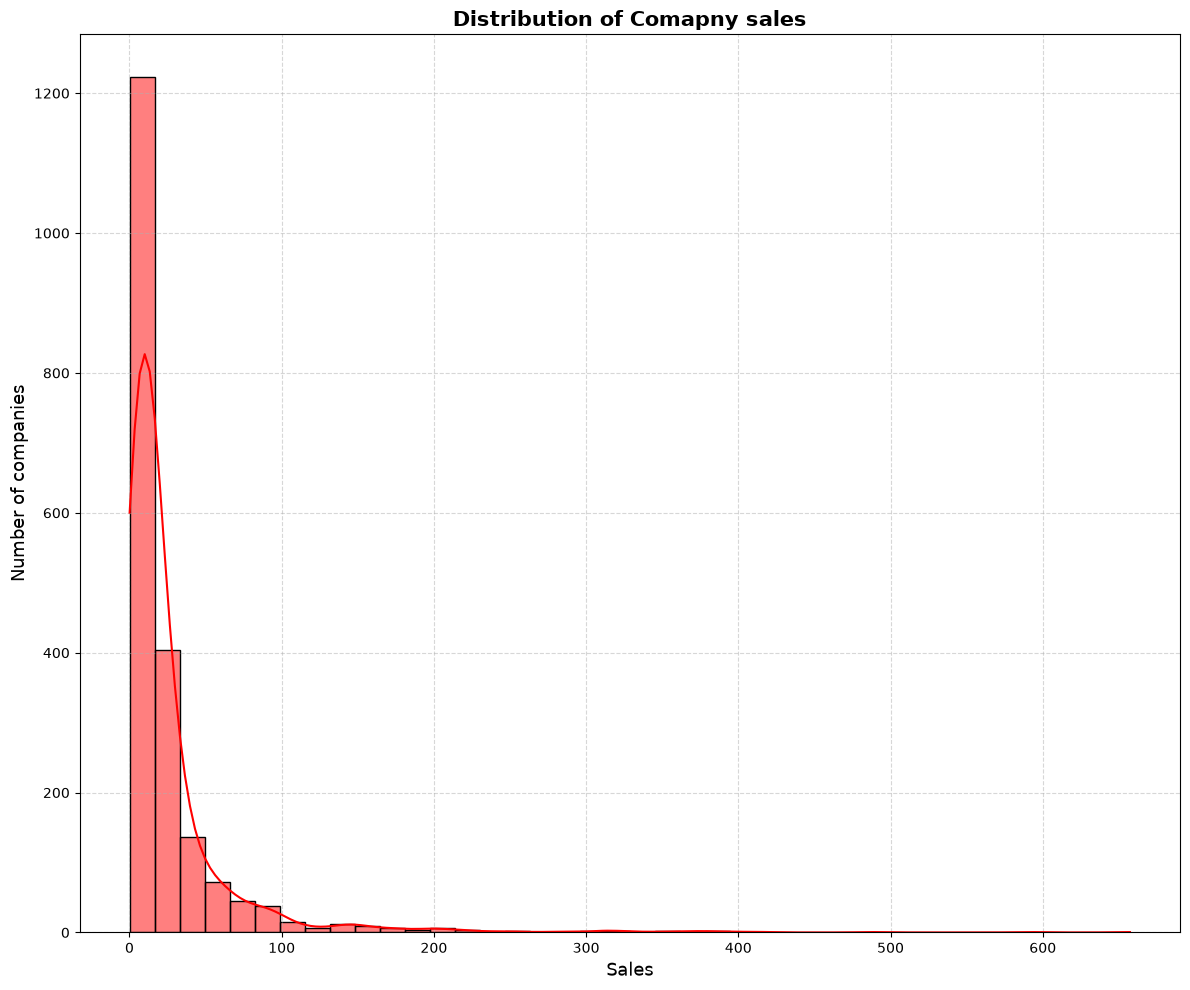

In [35]:
plt.figure(figsize= (12, 10))
sns.histplot(
    df['Sales'],
    bins= 40,
    kde= True,
    color= 'red'
)
plt.title(
    'Distribution of Comapny sales',
    fontweight= 'bold',
    fontsize= 15 
)
plt.xlabel(
    "Sales",
    fontsize= '13'
)
plt.ylabel(
    'Number of companies',
    fontsize= 13
)
plt.grid(
    axis= 'both',
    linestyle= '--',
    alpha= 0.5
)
plt.tight_layout()
plt.show()

## VISUALIZATION 2- TOP 10 COMPANIES BY SALE

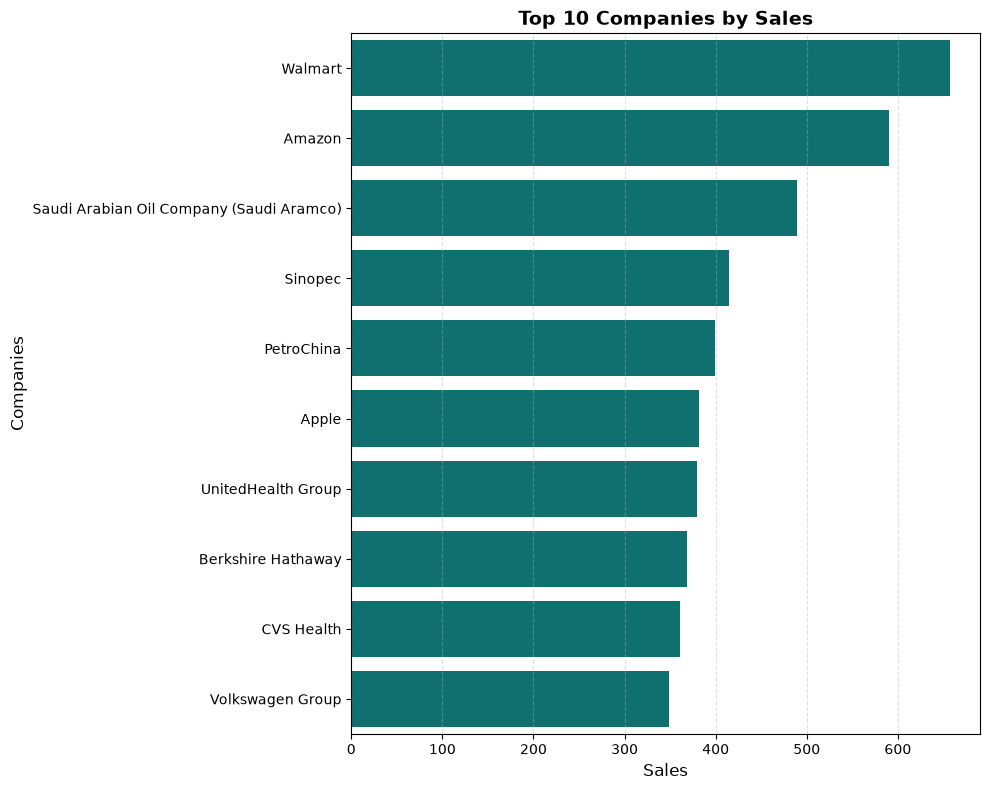

In [36]:
top_sales = df.nlargest(10, "Sales")
plt.figure(figsize= (10, 8))
sns.barplot(
    data= top_sales,
    x= 'Sales',
    y= 'Name',
    color= 'Teal'
)
plt.title(
    'Top 10 Companies by Sales',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Sales",
    fontsize= 12
)
plt.ylabel(
    'Companies',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 3- DISTRIBUTION OF PROFIT

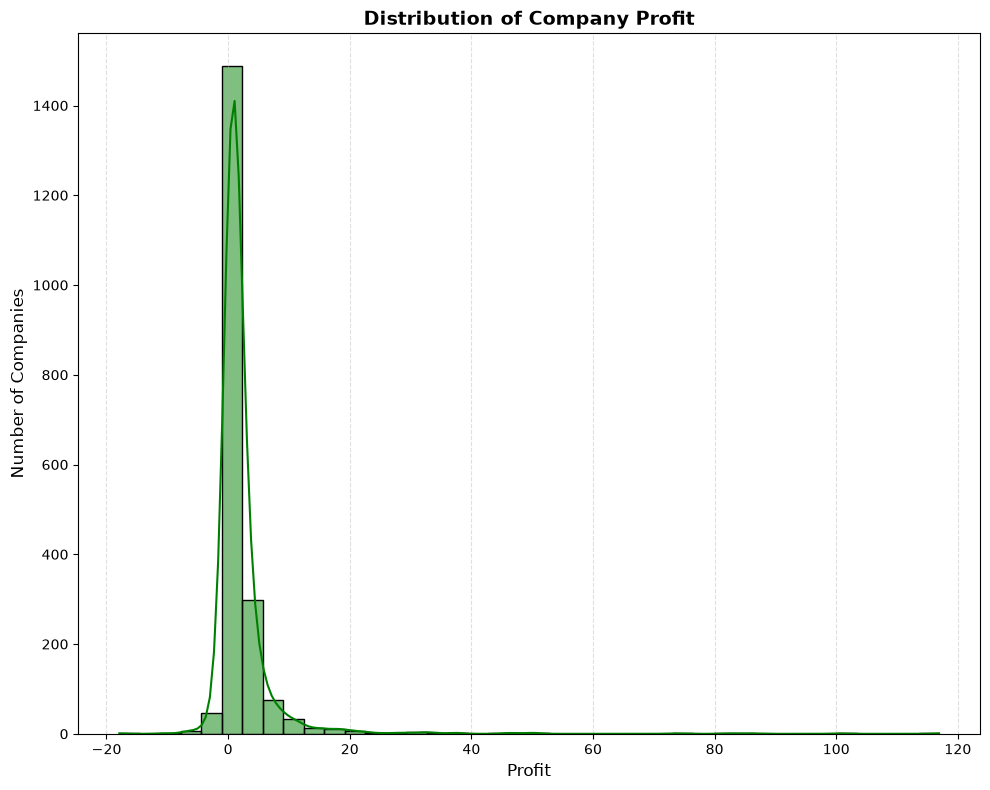

In [37]:
plt.figure(figsize= (10, 8))
sns.histplot(
    df['Profit'],
    bins= 40,
    kde= True,
    color= 'Green'
)
plt.title(
    'Distribution of Company Profit',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Profit",
    fontsize= 12
)
plt.ylabel(
    'Number of Companies',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()


## VISUALIZATION 4- DISTRIBUTION OF MARKET VALUE

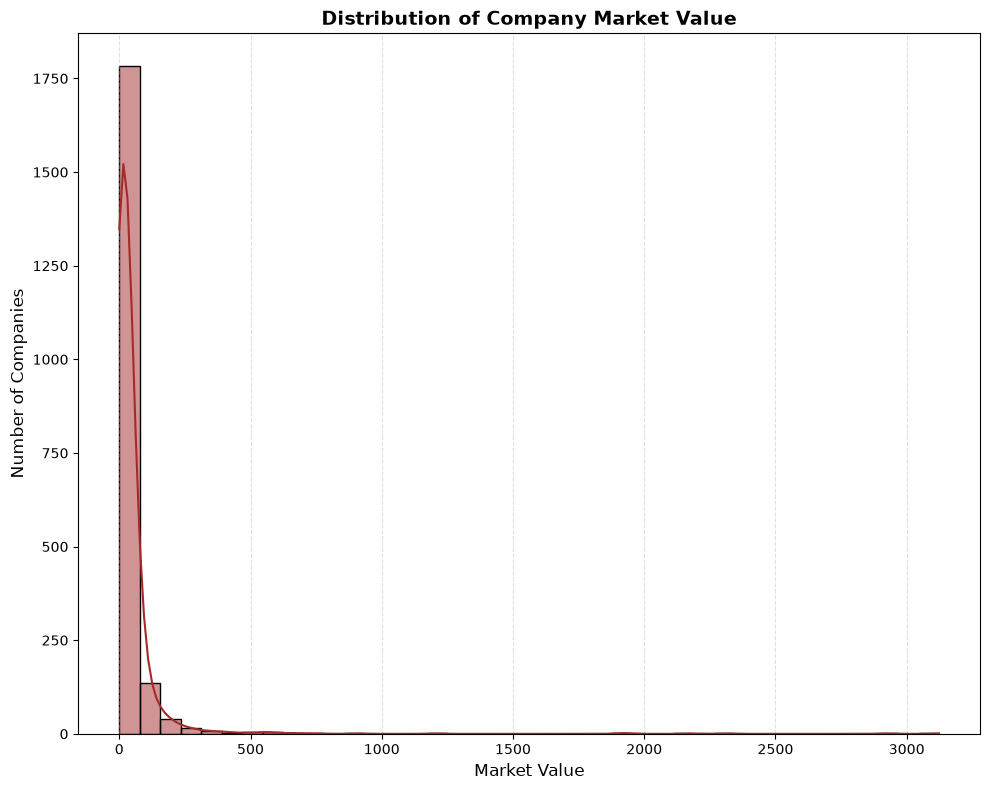

In [38]:
plt.figure(figsize= (10, 8))
sns.histplot(
    df['Market Value'],
    bins= 40,
    kde= True,
    color= 'Brown'
)
plt.title(
    'Distribution of Company Market Value',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Market Value",
    fontsize= 12
)
plt.ylabel(
    'Number of Companies',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 5- TOP 10 COMPANIES BY PROFIT

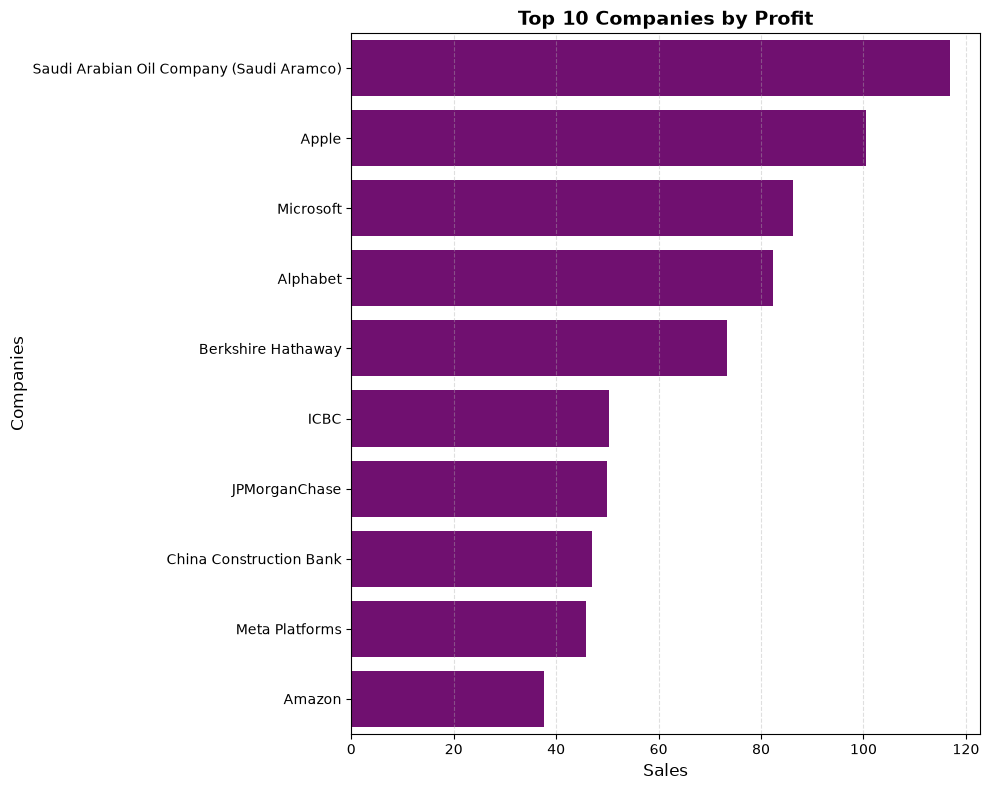

In [40]:
top_profits= df.nlargest(10, 'Profit')
plt.figure(figsize= (10, 8))
sns.barplot(
    data= top_profits,
    x= 'Profit',
    y= 'Name',
    color= 'Purple'
)
plt.title(
    'Top 10 Companies by Profit',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Sales",
    fontsize= 12
)
plt.ylabel(
    'Companies',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 6- COMPANIES BY COUNTRY 

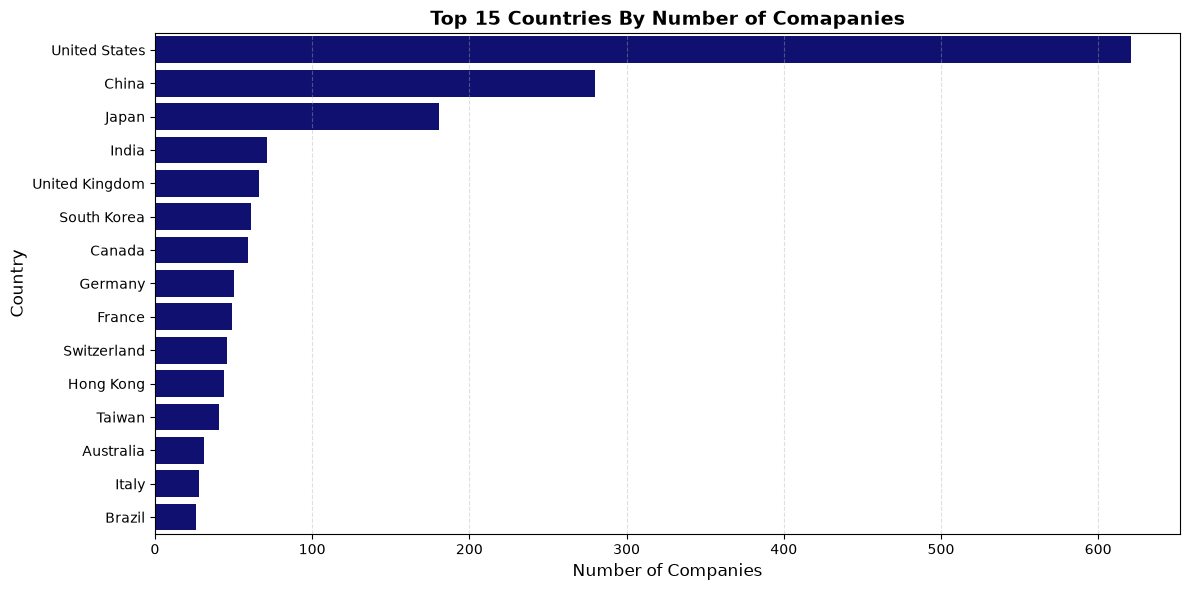

In [41]:
top_countries = df["Country"].value_counts().head(15)
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    color= 'navy'
)
plt.title(
    'Top 15 Countries By Number of Comapanies',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Number of Companies",
    fontsize= 12
)
plt.ylabel(
    'Country',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()


## VISUALIZATION 7- TOP 10 COMPANIES BY MARKET VALUE

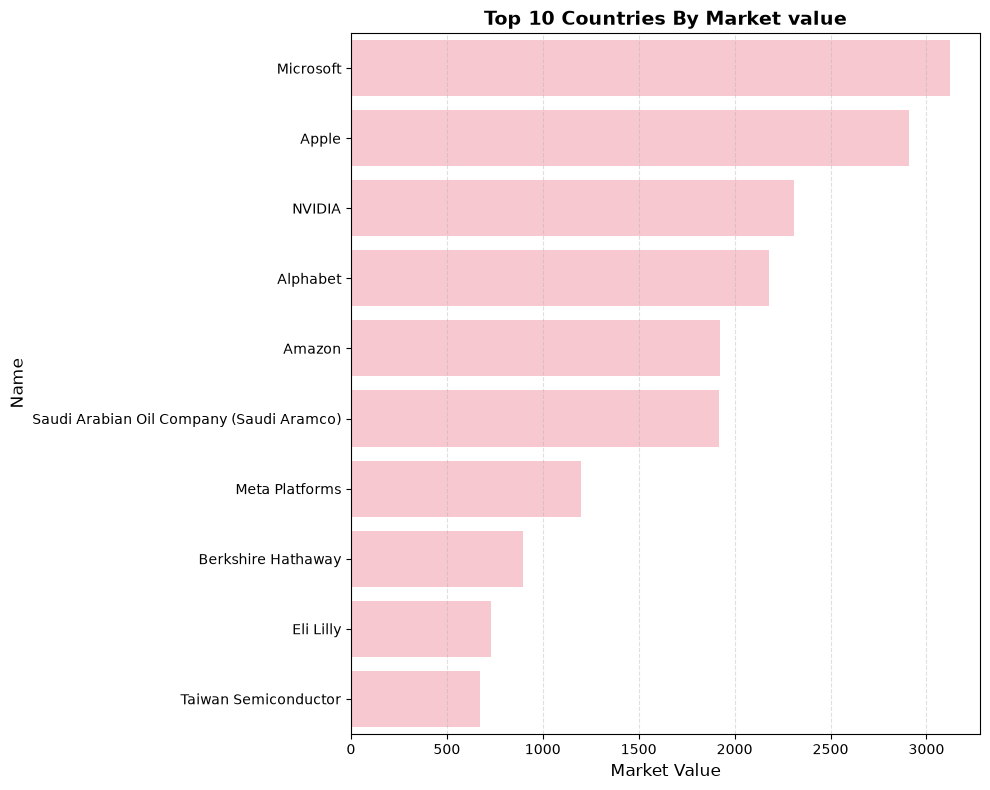

In [73]:
top_market = df.nlargest(10, "Market Value")
plt.figure(figsize=(10, 8))

sns.barplot(
    data= top_market,
    x='Market Value',
    y='Name',
    color= 'pink'
)
plt.title(
    'Top 10 Countries By Market value',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Market Value",
    fontsize= 12
)
plt.ylabel(
    'Name',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 8- AVERAGE PROFIT BY COUNTRY

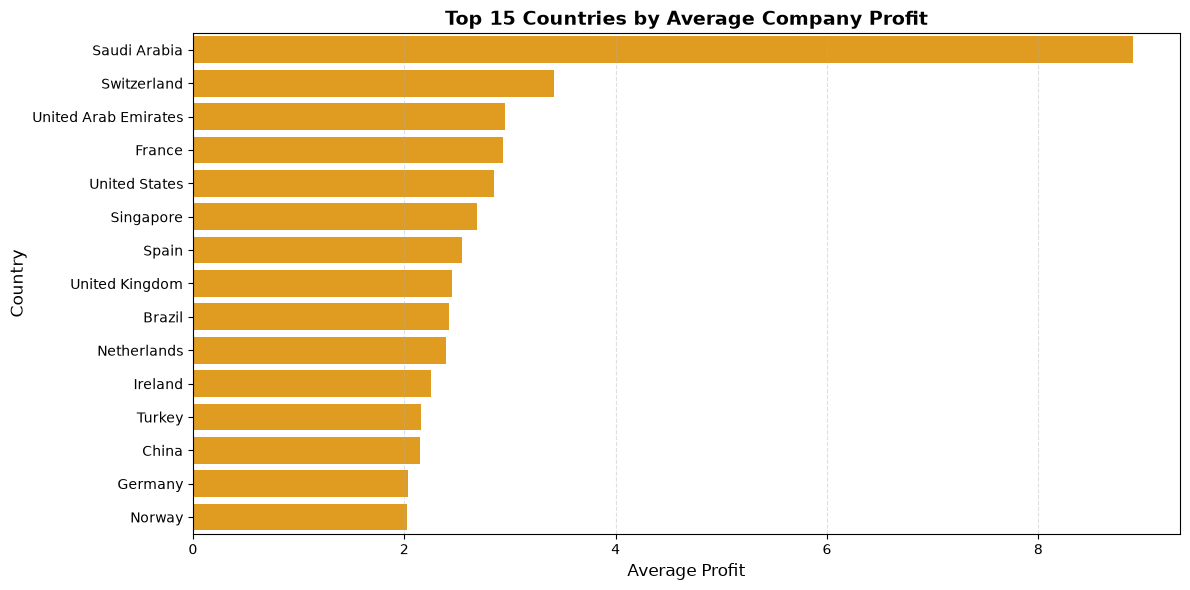

In [43]:
country_profit = (
    df.groupby("Country")["Profit"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=country_profit.values,
    y=country_profit.index,
    color= 'orange'
)
plt.title(
    'Top 15 Countries by Average Company Profit',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Average Profit",
    fontsize= 12
)
plt.ylabel(
    'Country',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 9- AVERAGE SALES BY COUNTRY 

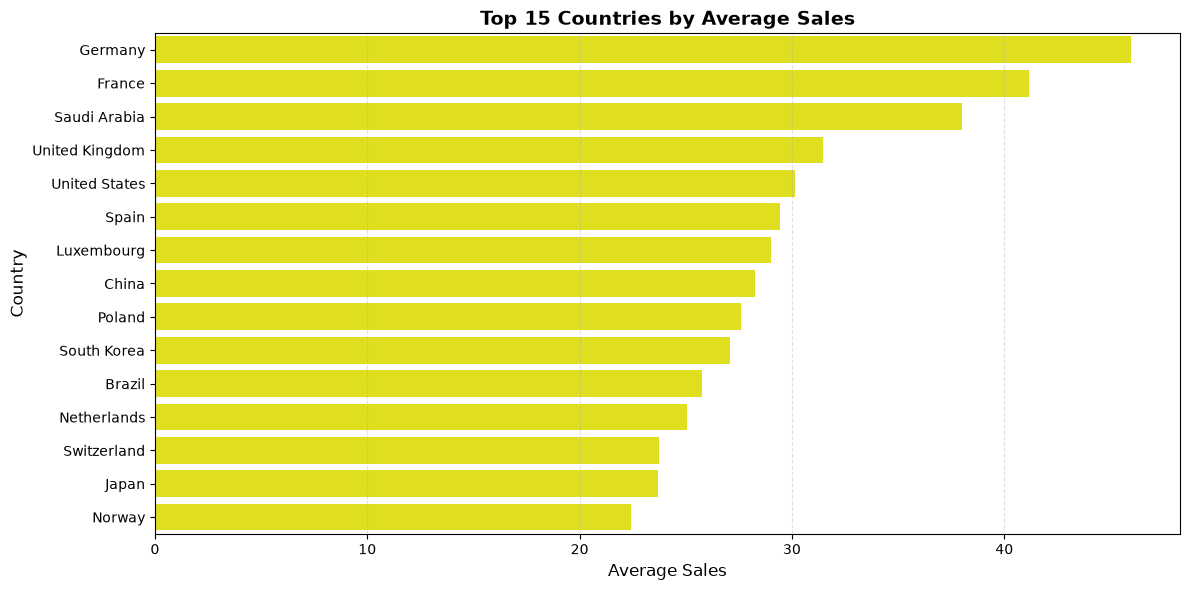

In [44]:
country_sales = (
    df.groupby("Country")["Sales"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=country_sales.values,
    y=country_sales.index,
    color= 'yellow'
)
plt.title(
    'Top 15 Countries by Average Sales',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Average Sales",
    fontsize= 12
)
plt.ylabel(
    'Country',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 10- PROFIT MARGIN DISTRIBUTION

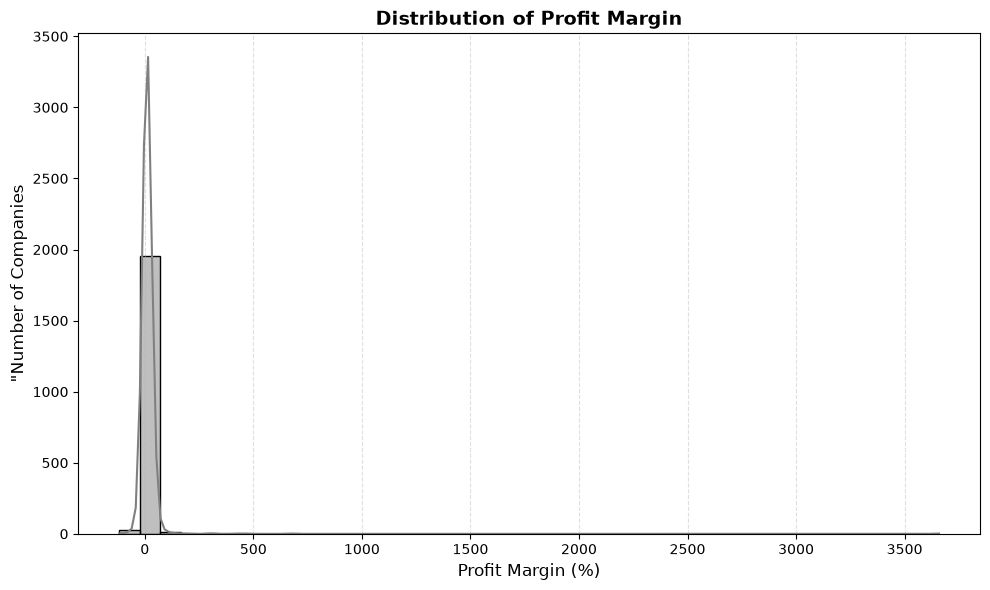

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Profit_Margin"].dropna(),
    bins=40,
    kde=True,
    color= 'grey'
)
plt.title(
    'Distribution of Profit Margin',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Profit Margin (%)",
    fontsize= 12
)
plt.ylabel(
    '"Number of Companies',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 11- SALES VS PROFIT

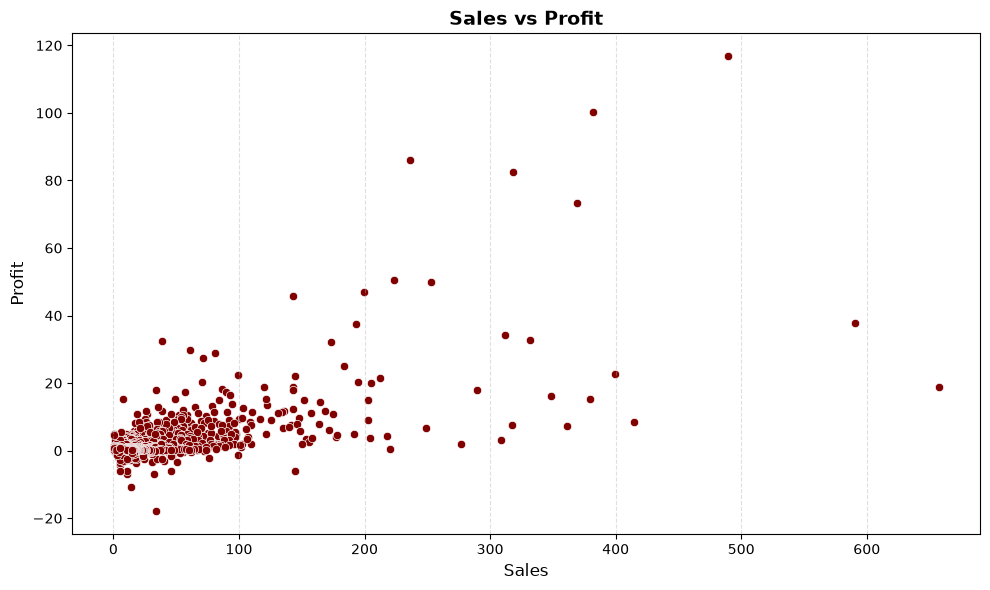

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    color= 'maroon'
)
plt.title(
    'Sales vs Profit',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Sales",
    fontsize= 12
)
plt.ylabel(
    'Profit',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 12- ASSETS VS MARKET VALUE

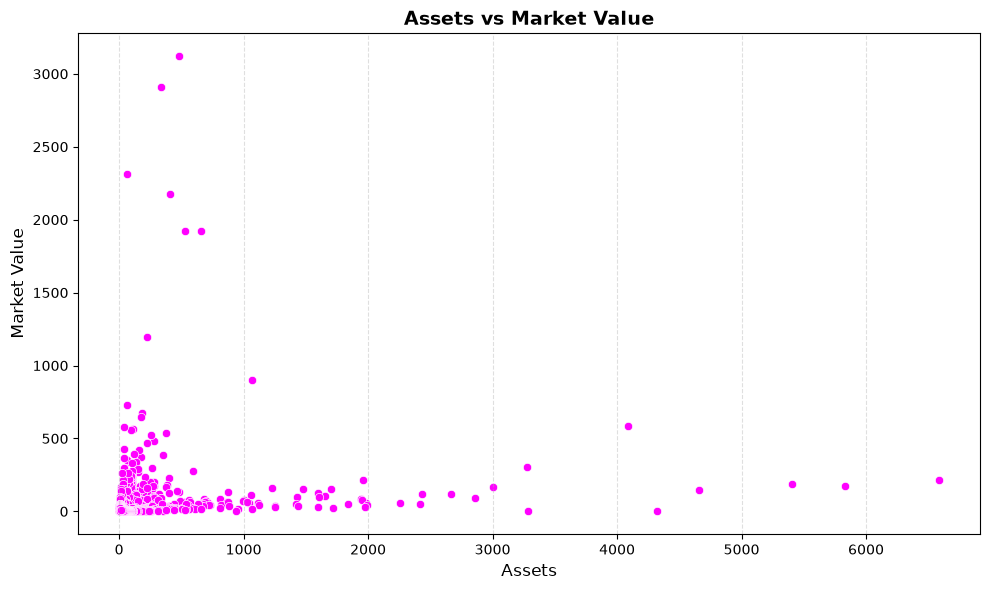

In [47]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Assets",
    y="Market Value",
    color= 'Magenta'
)
plt.title(
    'Assets vs Market Value',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Assets",
    fontsize= 12
)
plt.ylabel(
    'Market Value',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 13- SALES VS MARKET VALUE

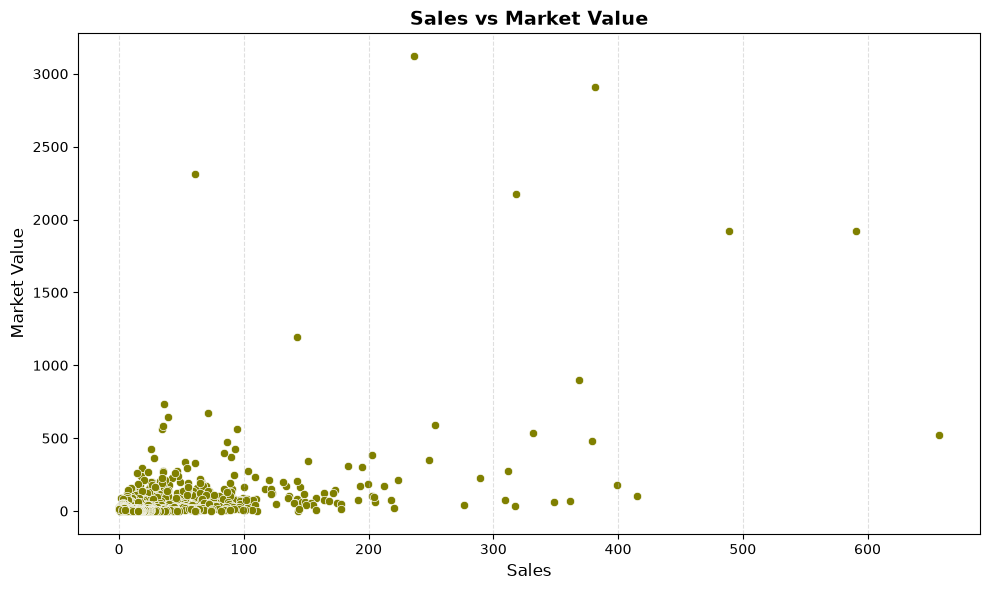

In [48]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Market Value",
    color= 'Olive'
)
plt.title(
    'Sales vs Market Value',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "Sales",
    fontsize= 12
)
plt.ylabel(
    'Market Value',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 14- ROA DISTRIBUTION 

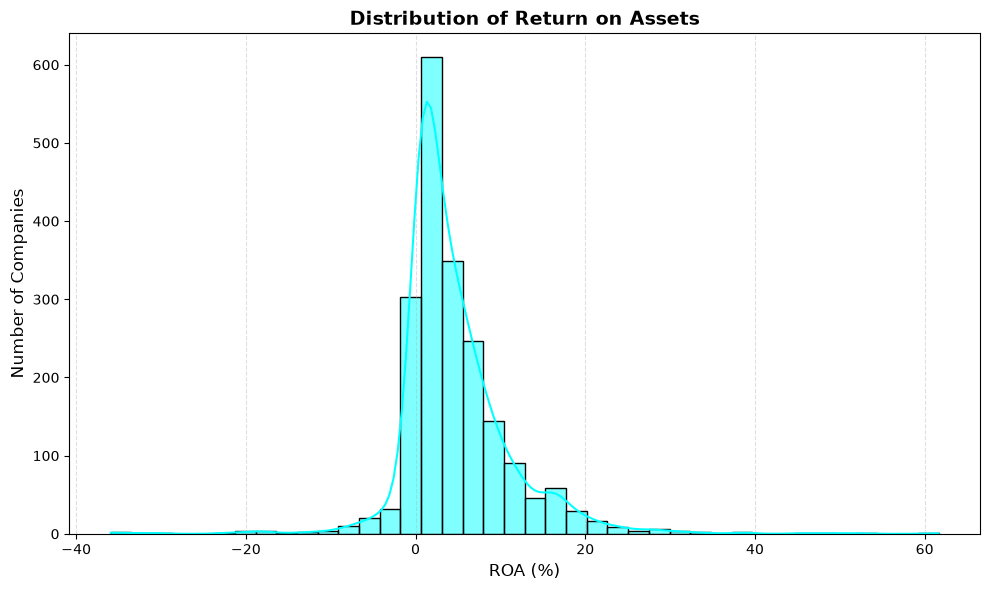

In [49]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Return on Assets"].dropna(), 
    bins=40, 
    kde=True,
    color= 'cyan'
)
plt.title(
    'Distribution of Return on Assets',
    fontsize= 14,
    fontweight= 'bold'
)
plt.xlabel(
    "ROA (%)",
    fontsize= 12
)
plt.ylabel(
    'Number of Companies',
    fontsize= 12
)
plt.grid(
    axis= 'x',
    linestyle= '--',
    alpha= 0.4
)
plt.tight_layout()
plt.show()

## VISUALIZATION 15 - CORRELATION HEATMAP

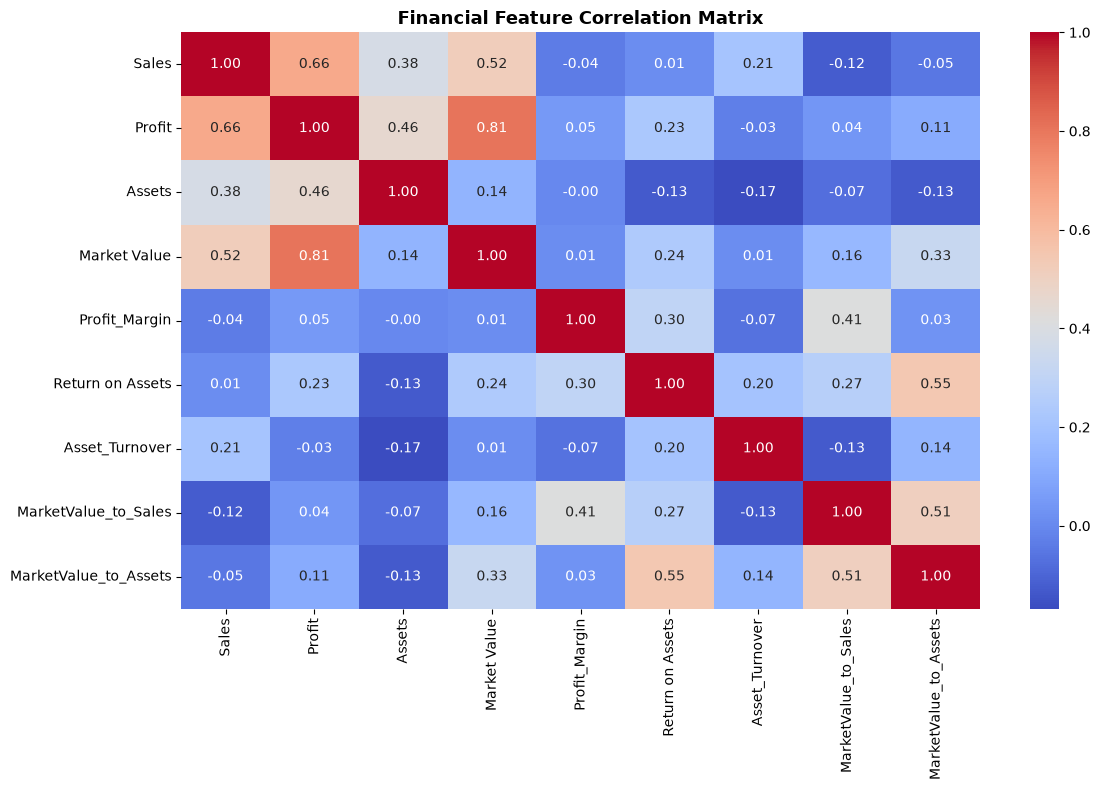

In [50]:
correlation_columns = [
    "Sales",
    "Profit",
    "Assets",
    "Market Value",
    "Profit_Margin",
    "Return on Assets",
    "Asset_Turnover",
    "MarketValue_to_Sales",
    "MarketValue_to_Assets"
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[correlation_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Financial Feature Correlation Matrix",
    fontsize= 13,
    fontweight= 'bold'
)
plt.tight_layout()
plt.show()

### KPI DEVELOPMENT

In [51]:
total_sales = df["Sales"].sum()

print(f"Total Sales: {total_sales:,.2f}")

Total Sales: 51,703.19


In [52]:
total_profit = df["Profit"].sum()

print(f"Total Profit: {total_profit:,.2f}")

Total Profit: 4,499.55


In [53]:
total_assets = df["Assets"].sum()

print(f"Total Assets: {total_assets:,.2f}")

Total Assets: 238,301.70


In [54]:
total_market_value = df["Market Value"].sum()

print(f"Total Market Value: {total_market_value:,.2f}")

Total Market Value: 88,453.74


In [55]:
average_sales = df["Sales"].mean()

print(f"Average Sales per Company: {average_sales:,.2f}")

Average Sales per Company: 25.84


In [56]:
average_sales = df["Sales"].mean()

print(f"Average Sales per Company: {average_sales:,.2f}")

Average Sales per Company: 25.84


In [57]:
overall_profit_margin = (
    df["Profit"].sum() / df["Sales"].sum()
) * 100

print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")

Overall Profit Margin: 8.70%


In [58]:
company_count = df["Name"].nunique()

print(f"Number of Companies: {company_count:,}")

Number of Companies: 2,001


In [59]:
country_count = df["Country"].nunique()

print(f"Number of Countries: {country_count:,}")

Number of Countries: 60


In [60]:
average_profit = df["Profit"].mean()

print(f"Average Profit per Company: {average_profit:,.2f}")

Average Profit per Company: 2.25


In [61]:
average_roa = df["Return on Assets"].mean()

print(f"Average ROA: {average_roa:.2f}%")

Average ROA: 4.65%


In [62]:
profitable_companies = (df["Profit"] > 0).sum()

print(f"Profitable Companies: {profitable_companies:,}")

Profitable Companies: 1,850


In [63]:
loss_making_companies = (df["Profit"] < 0).sum()

print(f"Loss-Making Companies: {loss_making_companies:,}")


Loss-Making Companies: 151


In [64]:
#KPI table 
kpi_table = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Assets",
        "Total Market Value",
        "Average Sales",
        "Average Profit",
        "Overall Profit Margin",
        "Average ROA",
        "Company Count",
        "Country Count",
        "Profitable Companies",
        "Loss-Making Companies"
    ],
    
    "Value": [
        total_sales,
        total_profit,
        total_assets,
        total_market_value,
        average_sales,
        average_profit,
        overall_profit_margin,
        average_roa,
        company_count,
        country_count,
        profitable_companies,
        loss_making_companies
    ]
})

kpi_table

,KPI,Value
0,Total Sales,51703.188000
1,Total Profit,4499.552300
2,Total Assets,238301.700000
3,Total Market Value,88453.741000
4,Average Sales,25.838675
5,Average Profit,2.248652
6,Overall Profit Margin,8.702659
7,Average ROA,4.654811
8,Company Count,2001.000000
9,Country Count,60.000000


### SAVE CLEANED CSV

In [65]:
df.to_csv(
    "Financial_Performance_Analytics_Cleaned.csv",
    index=False
)
print('Cleaned csv saved successfully!')

Cleaned csv saved successfully!


### BONUS- MACHINE LEARNING

## PREPARING DATA

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [67]:
features = ["Sales", "Assets", "Market Value"]
target = "Profit"

X = df[features]
y = df[target]

## SPLITTING DATA

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## TRAINING DATA

In [69]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## PREDICTING DATA

In [71]:
y_pred = model.predict(X_test)

## EVALUATING DATA

In [72]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.1281991966656324
RMSE: 2.276442544607169
R²: 0.6732488297519512


## INSIGHTS

1: Together the 2,001 companies made about $4.5 trillion in profit on $51.7 trillion in sales, an overall profit margin of 8.70%. They kept about $8.70 of every $100 they sold.

2: Company size is very uneven. Roughly 1,200 of the 2,001 companies (about 60%) have sales under roughly $16 billion, while a few are above $400 billion. The IQR method flagged 212 outliers in Sales, 242 in Profit, 241 in Assets and 198 in Market Value, around 10 to 12% of each column.

3: Walmart is the largest company by sales at roughly $660 billion, followed by Amazon at roughly $590 billion and Saudi Aramco at $489.1 billion.

4: Big sales do not guarantee big profit. Walmart earns only about $19 billion on its $660 billion in sales, a margin of around 3%, and it is not in the top 10 by profit. Amazon is second by sales but tenth by profit, at about $38 billion.

5: Saudi Aramco is the most profitable company at $116.9 billion, a margin of 23.9%. Apple is second (about $100 billion profit on about $382 billion sales), a margin of roughly 26%.

6: Technology companies dominate market value. Microsoft, Apple, NVIDIA, Alphabet and Amazon take the top five places, with Saudi Aramco close behind Amazon at $1,919.3 billion. NVIDIA is third (about $2.3 trillion) but is not in the top 10 by profit, which suggests its value reflects expected growth more than current earnings.

7: Market value is concentrated. The ten largest companies by market value add up to roughly a fifth of the total of about $88.5 trillion.

8: The United States has 621 companies (31%), China 280 and Japan about 180. Together they hold just over half of the list, and India, the United Kingdom and South Korea follow with 60 to 70 each.

9: Saudi Arabia has the highest average profit per company (about $8.9 billion), but it has only 16 companies and one of them is Aramco, so a single firm drives the average. Switzerland (about $3.4 billion) and the United States (about $2.85 billion) show broader strength.

10: Germany has the highest average sales (about $46 billion), then France (about $41 billion) and Saudi Arabia (about $38 billion). Germany's average profit is only around $2 billion, near the bottom of the top-15 profit list, so high sales do not always mean high profit at country level.

11: Profit is strongly linked to market value (correlation 0.81) and to sales (0.66). Its link with assets is weaker (0.46), and market value and assets are only 0.14 correlated.

12: Large assets do not make a company valuable in the market. The biggest asset values belong to banks such as ICBC ($6,586 billion) and JPMorgan Chase ($4,090.7 billion), yet ICBC's market value is only $215.2 billion, about 3% of its assets.

13: Return on assets is clustered at low values. Most companies fall between 0% and 10%, the peak is at about 1 to 3%, and the average is 4.65%. There is a long right tail up to about 60% and a small left tail down to about -36%.

14: About 92.5% of companies (1,850) made a profit and 151 (7.5%) made a loss. The biggest single loss is roughly $18 billion.

15: Profit margin has extreme values, reaching about 3,600% for at least one company. This usually comes from very small sales with a large profit, and such values should be checked or treated as outliers before margin is used further.

16:A linear regression using Sales, Assets and Market Value explains about 67% of the variation in profit (R-squared 0.673). The average error is $1.13 billion, about half of the average profit of $2.25 billion, so the model is useful but not precise.

## RECOMMENDATIONS

1: Do not rank companies by sales alone. Show profit margin and return on assets next to sales whenever companies are compared (Insights 3, 4).

2: Add an industry column and compare each company with similar companies. Margins range from about 3% for Walmart to more than 20% for Apple and Aramco, so one margin target for everyone would mislead (Insights 4, 5).

3: Use medians and a minimum company count when comparing countries. Saudi Arabia tops the average profit chart with only 16 companies, so countries with very few companies should carry a warning or be left out of rankings (Insight 9).

4: Keep a watchlist of the 151 loss-making companies and review their ROA and profit every year. A company that is both loss-making and low in ROA deserves closer attention (Insights 13, 14).

5: Do not base conclusions only on the United States, China and Japan. Benchmarks should also include India, the United Kingdom, South Korea and Canada (Insight 8).

6: Use market value as a rough signal of earning power, since it moves with profit (0.81), but check exceptions like NVIDIA, which ranks high in market value but not in profit (Insights 6, 11).

7: Judge banks and other asset-heavy companies by ROA and market value to assets, not by the size of their assets (Insight 12).

8: Split companies into size groups (large, medium, small by sales) and analyse each separately. About 60% are small compared with a few giants, so one overall average hides what is typical (Insights 2, 7).

9: Check and clean the extreme profit margin values before using margin in dashboards or models. Cap them or analyse those few companies separately (Insight 15).

10: Improve the model by log-transforming the skewed columns, adding ratio features, and testing a Random Forest. The R-squared of 0.673 is a clear baseline to beat (Insight 16).